# **MUSHROOM CLASSIFICATION**

### VEDANT BHAGAT
### B4-B1
### ROLL NO. 16

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

###**Dataset Loading and Exploration**


### **EDA**


In [9]:
df = pd.read_csv('/content/mushrooms.csv')
df

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [10]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [11]:
df.shape

(8124, 23)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [13]:
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [14]:
df.isnull()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8120,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8121,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8122,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [15]:
df.isnull().sum()

,0
class,0
cap-shape,0
cap-surface,0
cap-color,0
bruises,0
odor,0
gill-attachment,0
gill-spacing,0
gill-size,0
gill-color,0


In [16]:
df['class'].value_counts()

,count
class,
e,4208
p,3916


<function matplotlib.pyplot.show(close=None, block=None)>

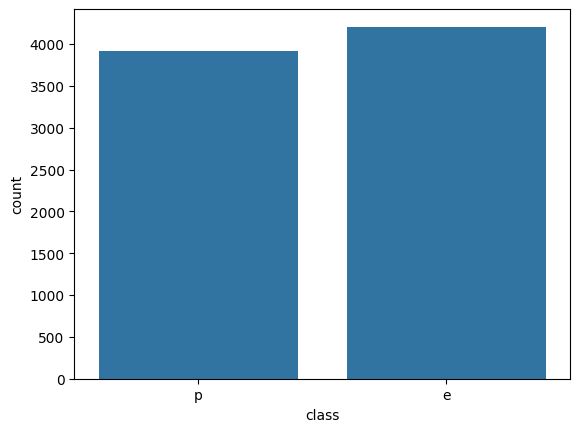

In [17]:
sns.countplot(x='class', data=df)
plt.show

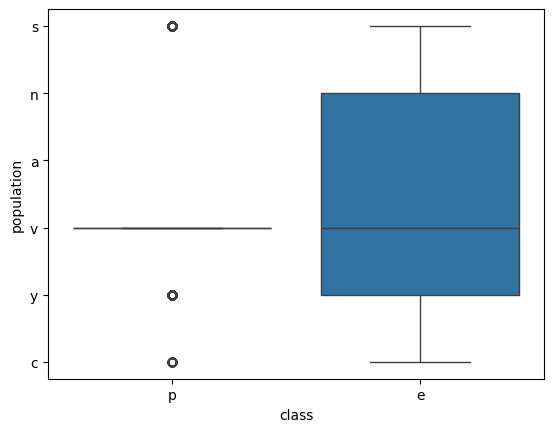

In [18]:
sns.boxplot(x='class', y='population', data=df)
plt.show()

### Data Preprocessing

In [19]:
y = df['class'].map({'e': 0, 'p': 1})
X = pd.get_dummies(df.drop('class', axis=1))

In [20]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8124, 117)
y shape: (8124,)


### Feature Extraction

In [21]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

fs_model = RandomForestClassifier(random_state=42)
fs_model.fit(X, y)

importances = pd.Series(fs_model.feature_importances_, index=X.columns)

important_features = importances.sort_values(ascending=False)

top_n = 10
selected_features = important_features[:top_n].index

X = X[selected_features]

print("Selected Features:", list(selected_features))

Selected Features: ['odor_n', 'gill-size_n', 'odor_f', 'gill-size_b', 'stalk-surface-below-ring_k', 'spore-print-color_h', 'gill-color_b', 'ring-type_p', 'stalk-surface-above-ring_k', 'bruises_f']


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Training Multiple Classification Models

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(max_depth=5, n_estimators=50, random_state=42),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

### Performance Evaluation and Model Comparison

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = []

for name, model in models.items():

    if name in ["SVM", "KNN", "Logistic Regression"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print(results_df.sort_values(by="Accuracy", ascending=False))

                 Model  Accuracy  Precision    Recall  F1 Score
1        Decision Tree  0.977846   0.972187  0.982120  0.977128
3                  SVM  0.977846   0.972187  0.982120  0.977128
2        Random Forest  0.977846   0.972187  0.982120  0.977128
0  Logistic Regression  0.976000   0.972081  0.978289  0.975175
4                  KNN  0.953231   1.000000  0.902937  0.948993


In [26]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

best_model = RandomForestClassifier(max_depth=5, n_estimators=50)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(best_model, X, y, cv=cv)

print("Cross Validation Scores:", scores)
print("Mean Accuracy:", scores.mean())

Cross Validation Scores: [0.976      0.98092308 0.98646154 0.96923077 0.97906404]
Mean Accuracy: 0.9783358848048505


### Best Model Selection

In [27]:
best_model = max(results, key=lambda x: x["F1 Score"])
print("Best Model:", best_model["Model"])
print("Accuracy:", best_model["Accuracy"])
print("Precision:", best_model["Precision"])
print("Recall:", best_model["Recall"])
print("F1 Score:", best_model["F1 Score"])

Best Model: Decision Tree
Accuracy: 0.9778461538461538
Precision: 0.9721871049304678
Recall: 0.9821200510855683
F1 Score: 0.97712833545108


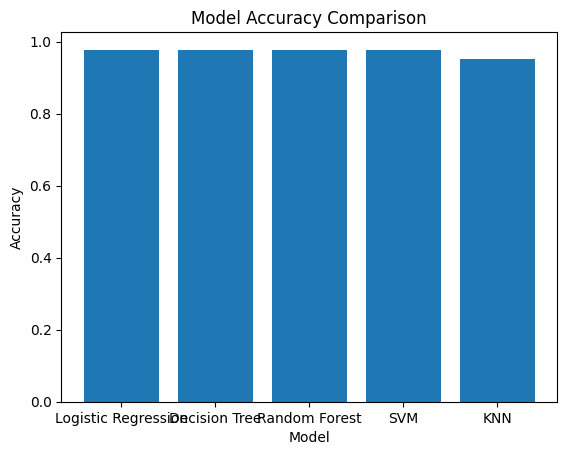

In [28]:
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

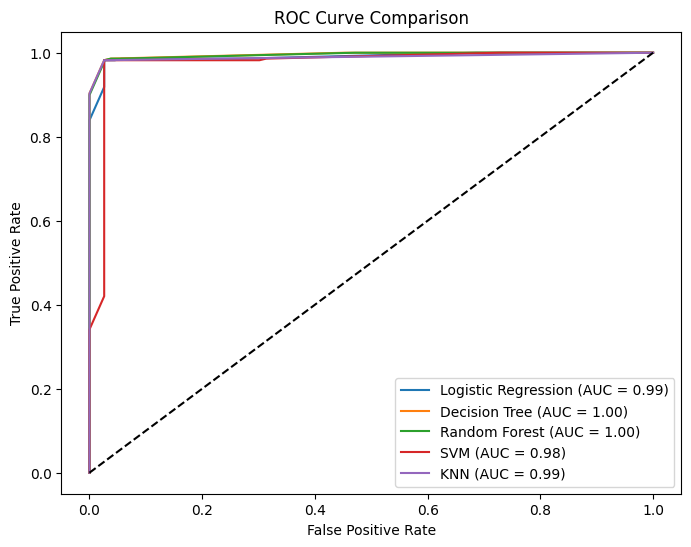

In [29]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for name, model_instance in models.items():

    if name in ["SVM", "KNN", "Logistic Regression"]:
        model_instance.fit(X_train_scaled, y_train)

        if hasattr(model_instance, "predict_proba"):
            y_pred_prob = model_instance.predict_proba(X_test_scaled)[:, 1]
        else:
            y_pred_prob = model_instance.decision_function(X_test_scaled)

    else:
        model_instance.fit(X_train, y_train)
        y_pred_prob = model_instance.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [30]:
best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)
pred_rf=best_model.predict(X_test)

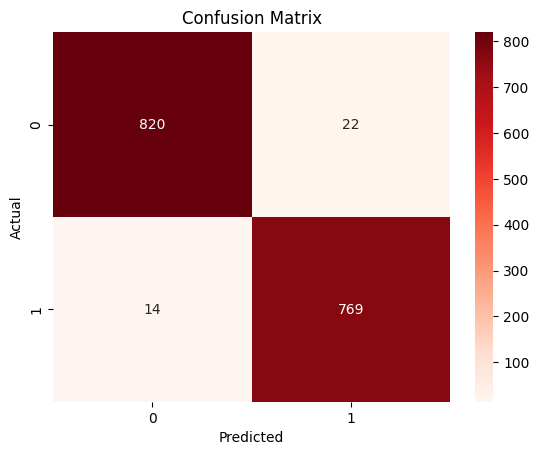

In [31]:
cm = confusion_matrix(y_test, pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [32]:
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       842
           1       0.97      0.98      0.98       783

    accuracy                           0.98      1625
   macro avg       0.98      0.98      0.98      1625
weighted avg       0.98      0.98      0.98      1625



### GUI Implementation

In [37]:
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

best_model = RandomForestClassifier()

scaler = StandardScaler()

with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Model and Scaler saved")

Model and Scaler saved


In [44]:
import pickle
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
import pandas as pd

gui_columns = ['odor', 'gill-size', 'stalk-surface-below-ring',
               'spore-print-color', 'gill-color', 'ring-type',
               'stalk-surface-above-ring', 'bruises']

y_gui = df['class'].map({'e': 0, 'p': 1})
X_gui = df[gui_columns]
X_gui_encoded = pd.get_dummies(X_gui)

X_train_gui, X_test_gui, y_train_gui, y_test_gui = train_test_split(
    X_gui_encoded, y_gui, test_size=0.2, random_state=7
)

scaler_gui = StandardScaler()
X_train_scaled_gui = scaler_gui.fit_transform(X_train_gui)

hybrid_model_gui = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression()),
        ('svm', SVC(probability=True)),
        ('xgb', XGBClassifier())
    ],
    voting='soft'
)
hybrid_model_gui.fit(X_train_scaled_gui, y_train_gui)

import pickle
with open('best_model.pkl', 'wb') as f:
    pickle.dump(hybrid_model_gui, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler_gui, f)
with open('gui_columns.pkl', 'wb') as f:
    pickle.dump(list(X_gui_encoded.columns), f)

print("Model, Scaler, and Column list saved")

Model, Scaler, and Column list saved


In [41]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 50.3 MB/s eta 0:00:00


In [45]:
%%writefile app.py
import streamlit as st
import numpy as np
import pandas as pd
import pickle

with open('best_model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open('gui_columns.pkl', 'rb') as f:
    expected_columns = pickle.load(f)

OPTIONS = {
    'odor':                     ['a','c','f','l','m','n','p','s','y'],
    'gill-size':                ['b','n'],
    'stalk-surface-below-ring': ['f','k','s','y'],
    'spore-print-color':        ['b','h','k','n','o','r','u','w','y'],
    'gill-color':               ['b','e','g','h','k','n','o','p','r','u','w','y'],
    'ring-type':                ['e','f','l','n','p'],
    'stalk-surface-above-ring': ['f','k','s','y'],
    'bruises':                  ['f','t'],
}

LABELS = {
    'odor':                     {'a':'Almond','c':'Creosote','f':'Foul','l':'Anise',
                                  'm':'Musty','n':'None','p':'Pungent','s':'Spicy','y':'Fishy'},
    'gill-size':                {'b':'Broad','n':'Narrow'},
    'stalk-surface-below-ring': {'f':'Fibrous','k':'Silky','s':'Smooth','y':'Scaly'},
    'spore-print-color':        {'b':'Buff','h':'Chocolate','k':'Black','n':'Brown',
                                  'o':'Orange','r':'Green','u':'Purple','w':'White','y':'Yellow'},
    'gill-color':               {'b':'Buff','e':'Red','g':'Gray','h':'Chocolate','k':'Black',
                                  'n':'Brown','o':'Orange','p':'Pink','r':'Green',
                                  'u':'Purple','w':'White','y':'Yellow'},
    'ring-type':                {'e':'Evanescent','f':'Flaring','l':'Large','n':'None','p':'Pendant'},
    'stalk-surface-above-ring': {'f':'Fibrous','k':'Silky','s':'Smooth','y':'Scaly'},
    'bruises':                  {'f':'No','t':'Yes'},
}

st.title("🍄 Mushroom Classification System")
st.write("Select mushroom features below to predict if it is **edible** or **poisonous**.")

user_input = {}
col1, col2 = st.columns(2)
features = list(OPTIONS.keys())

for i, feat in enumerate(features):
    col = col1 if i % 2 == 0 else col2
    opts = OPTIONS[feat]
    display = [f"{v} — {LABELS[feat][v]}" for v in opts]
    choice = col.selectbox(feat.replace('-', ' ').title(), display, key=feat)
    user_input[feat] = choice.split(' — ')[0]

if st.button("Predict"):
    try:
        input_df = pd.DataFrame([user_input])
        input_encoded = pd.get_dummies(input_df)

        input_aligned = input_encoded.reindex(columns=expected_columns, fill_value=0)

        input_scaled = scaler.transform(input_aligned)
        prediction = model.predict(input_scaled)[0]

        if prediction == 0:
            st.success("✅ Predicted: EDIBLE — This mushroom appears safe to eat.")
        else:
            st.error("☠️ Predicted: POISONOUS — Do NOT eat this mushroom!")
    except Exception as e:
        st.error(f"Error: {str(e)}")

Overwriting app.py


In [46]:
!pip install streamlit pyngrok --quiet
from pyngrok import ngrok
ngrok.set_auth_token('3C8FZutBds90ym4Q8ZecGC8Av4n_5Y71NaMJTMudkYQi7dGvQ')
ngrok.kill()
get_ipython().system_raw("streamlit run app.py &")
url = ngrok.connect(addr='8501')
url

<NgrokTunnel: "https://drizzle-skimming-rockband.ngrok-free.dev" -> "http://localhost:8501">